# CVL Assignment 2
```
Name    : Shadiq Arif Aryasatya
NIM     : 24/536702/PA/22763
Class   : CS
Subject : Computer Vision and Image Analysis
```

For this assignment, I have chosen to use the thresholding method, specifically Otsu's thresholding, to perform object detection on a microscopic view of white blood cells, specifically Granulocytes. The source for the image is https://www.microscopemaster.com/white-blood-cells.html#gallery[pagegallery]/2/.

Threshold: 226
Accuracy: 57.49%
IoU: 0.3168


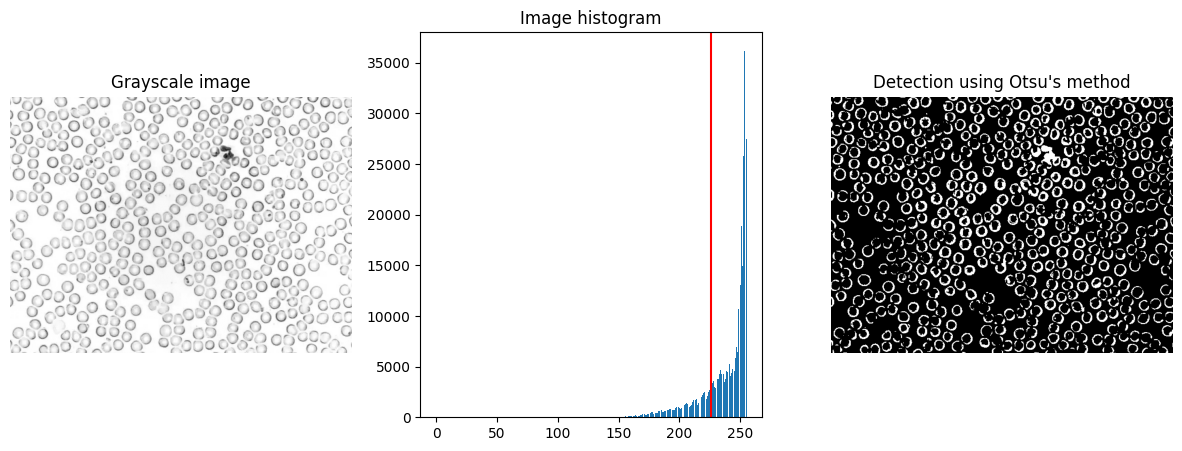

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def object_detection_otsu_method(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        raise ValueError("Image not found.")

    height, width = image.shape
    total_pixels = height * width

    # creating the histogram
    hist = np.zeros(256)
    for i in range(height):
        for j in range(width):
            hist[image[i, j]] += 1

    current_max_variance = 0
    optimal_threshold = 0
    sum_total = sum(i * hist[i] for i in range(256))

    sum_background = 0
    weight_background = 0

    # Otsu's method calculation
    for t in range(256):
        weight_background += hist[t]
        if weight_background == 0: continue

        weight_foreground = total_pixels - weight_background
        if weight_foreground == 0: break

        sum_background += t * hist[t]

        mean_b = sum_background / weight_background
        mean_f = (sum_total - sum_background) / weight_foreground

        # between-class variance
        var_between = weight_background * weight_foreground * (mean_b - mean_f) ** 2

        if var_between > current_max_variance:
            current_max_variance = var_between
            optimal_threshold = t

    # anything below the threshold is dark
    detected_objects = np.zeros((height, width), dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            if image[i, j] < optimal_threshold:
                detected_objects[i, j] = 255

    return image, detected_objects, optimal_threshold, hist

def manual_metrics(predicted_mask, ground_truth_path):
    gt_img = cv2.imread(ground_truth_path, cv2.IMREAD_GRAYSCALE)
    if gt_img is None:
        return None, None

    height, width = predicted_mask.shape

    tp = 0 # true positive (both: cell)
    tn = 0 # true negative (both: background)
    fp = 0 # false positive (prediction: cell, ground truth: background)
    fn = 0 # false negative (prediction: background, ground truth: cell)

    for i in range(height):
        for j in range(width):
            # ground truth binarized
            gt_val = 255 if gt_img[i, j] > 127 else 0
            pred_val = predicted_mask[i, j]

            if pred_val == 255 and gt_val == 255:
                tp += 1
            elif pred_val == 0 and gt_val == 0:
                tn += 1
            elif pred_val == 255 and gt_val == 0:
                fp += 1
            elif pred_val == 0 and gt_val == 255:
                fn += 1

    # accuracy calculation
    accuracy = (tp + tn) / (height * width)

    # IoU calculation
    intersection = tp
    union = tp + fp + fn
    iou = intersection / union if union != 0 else 0.0

    return accuracy, iou


image_file = 'cell_image.webp'
gt_file = 'cell_image_ground_truth.jpg'

try:
    original, mask, thresh, hist = object_detection_otsu_method(image_file)
    acc, iou = manual_metrics(mask, gt_file)

    print(f"Threshold: {thresh}")
    if acc is not None:
        print(f"Accuracy: {acc * 100:.2f}%")
        print(f"IoU: {iou:.4f}")

    # image plotting and visualization
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1); plt.title("Grayscale image"); plt.imshow(original, cmap='gray'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.title("Image histogram"); plt.bar(range(256), hist); plt.axvline(thresh, color='r')
    plt.subplot(1, 3, 3); plt.title("Detection using Otsu's method"); plt.imshow(mask, cmap='gray'); plt.axis('off')
    plt.show()

except Exception as e:
    print(f"Error: {e}")

In the end, the prediction came out to have an accuracy of 57.49%, as well as an IoU of 0.3168. While not highly accurate, it could be noted that the some cells may be noted as a background, as most of them seem to have the same color as it, with some lighting make it look like the background is "leaking" into the cell.